Simple Linear Regression

Load and import the libraries

In [ ]:
# Basic libraries for data handling and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Load the Boston dataset
df = pd.read_csv("/content/Salary_dataset.csv")

# Show first 5 rows
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


Describe the datset

In [ ]:
# Number of rows and columns
print(df.shape)

# Column names
print(df.columns)

# Basic statistics
print(df.describe())

(30, 3)
Index(['Unnamed: 0', 'YearsExperience', 'Salary'], dtype='object')
       Unnamed: 0  YearsExperience         Salary
count   30.000000        30.000000      30.000000
mean    14.500000         5.413333   76004.000000
std      8.803408         2.837888   27414.429785
min      0.000000         1.200000   37732.000000
25%      7.250000         3.300000   56721.750000
50%     14.500000         4.800000   65238.000000
75%     21.750000         7.800000  100545.750000
max     29.000000        10.600000  122392.000000


Remove unneccesary columns before the training

In [ ]:
# Sometimes Boston dataset contains an index column called 'Unnamed: 0'
# It is useless for prediction, so we remove it

if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


Check if any column has missing values

In [ ]:
# Check if any column has missing values
df.isnull().sum()

,0
YearsExperience,0
Salary,0


Select the target and dependent columns

In [ ]:
# Target variable (what we want to predict)
y = df['Salary']   # median house price

# Features (everything else)
X = df.drop('Salary', axis=1)

Train-test split

In [ ]:
# 80% training, 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Creat the model and fit it to the dataset

In [ ]:
# Create model
model = LinearRegression()

# Train model using training data
model.fit(X_train, y_train)

LinearRegression()

Check for predictions

In [ ]:
# Predict on test data
y_pred = model.predict(X_test)

# Show first 5 predictions
print(y_pred[:5])

[115791.21011287  71499.27809463 102597.86866063  75268.80422384
  55478.79204548]


Evaluation of the model performance

In [ ]:
# Mean Squared Error (lower is better)
mse = mean_squared_error(y_test, y_pred)

# R2 Score (closer to 1 is better)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 49830096.855908394
R2 Score: 0.9024461774180497


Predicted vs actual values plot

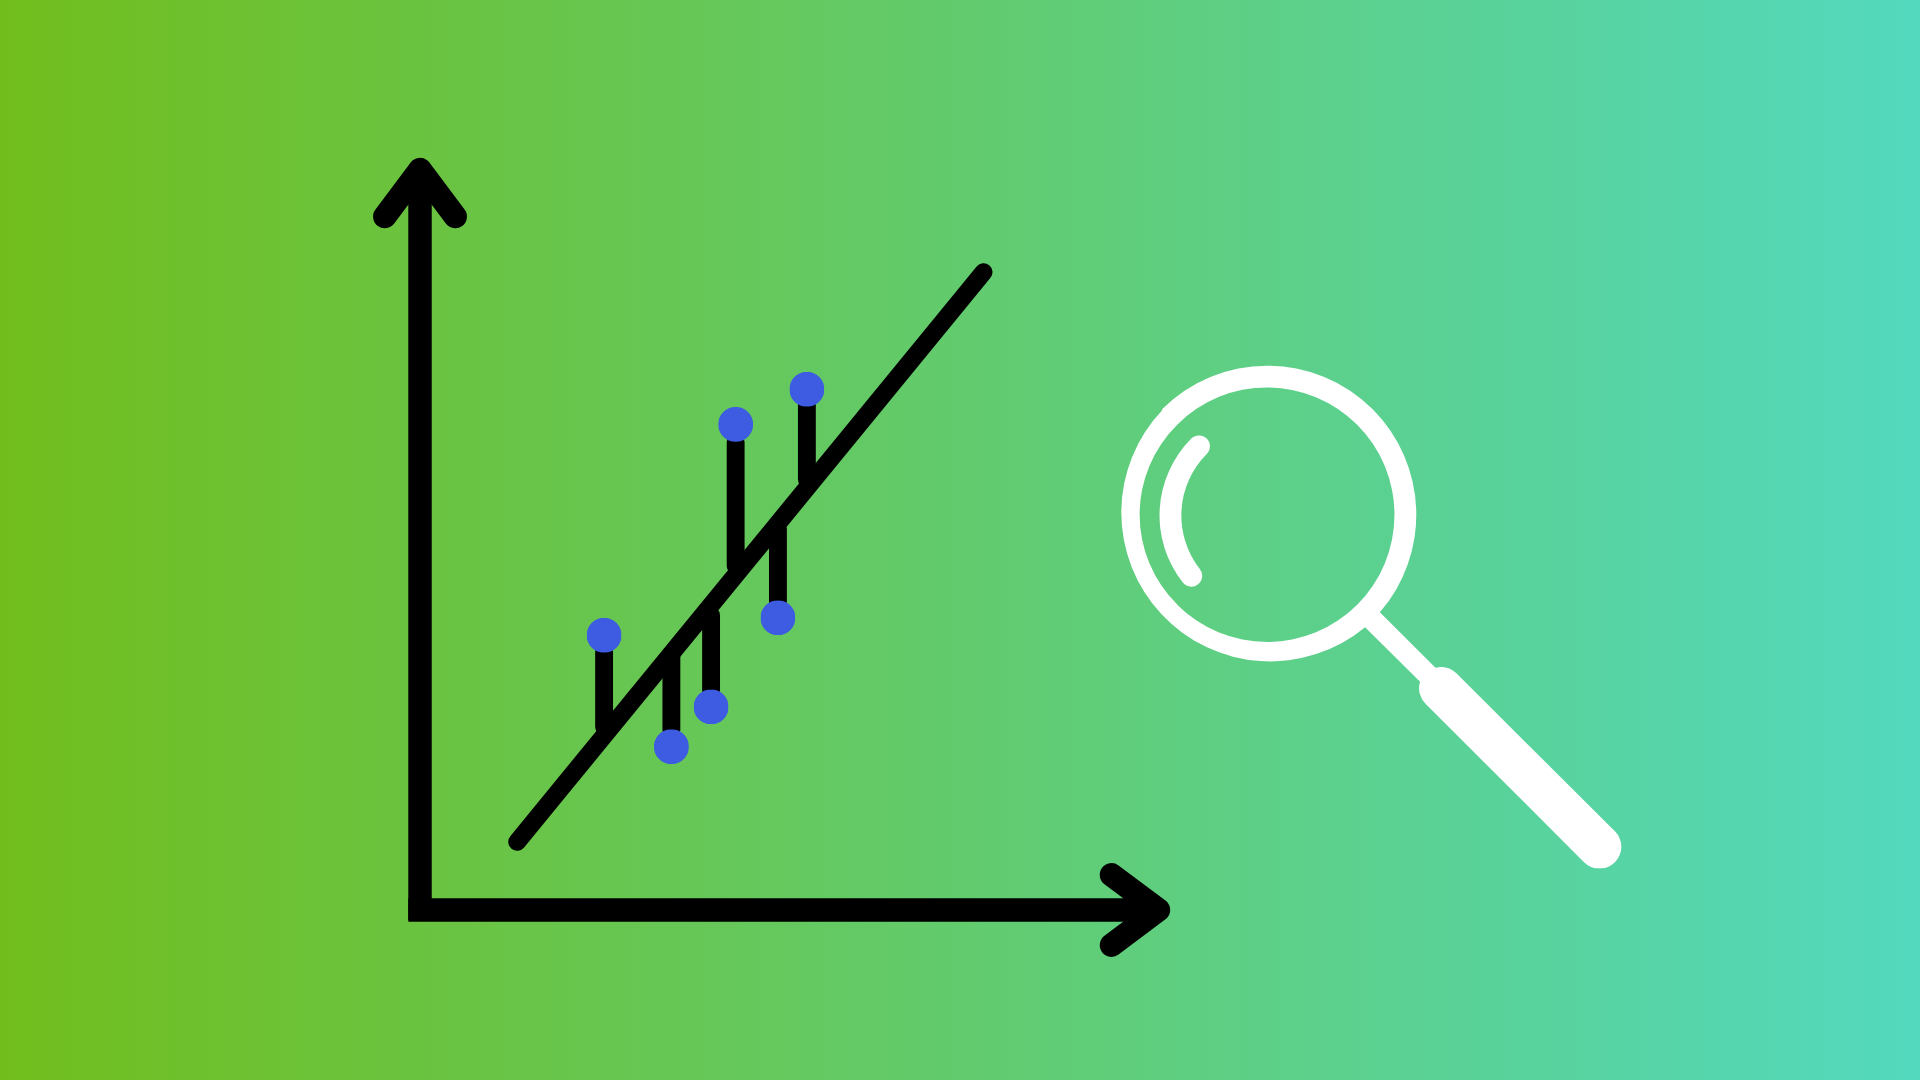

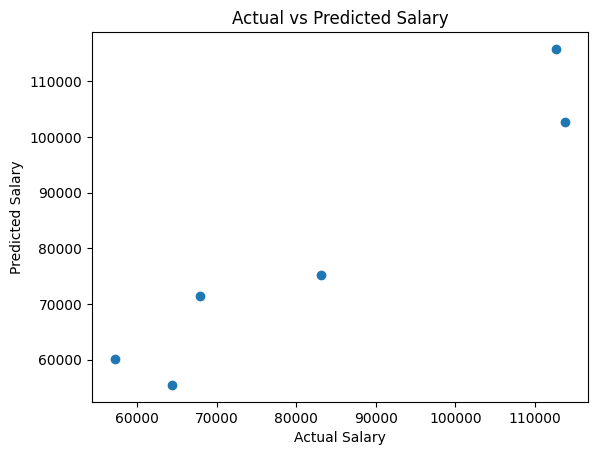

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()
#If points form diagonal line → model is good.

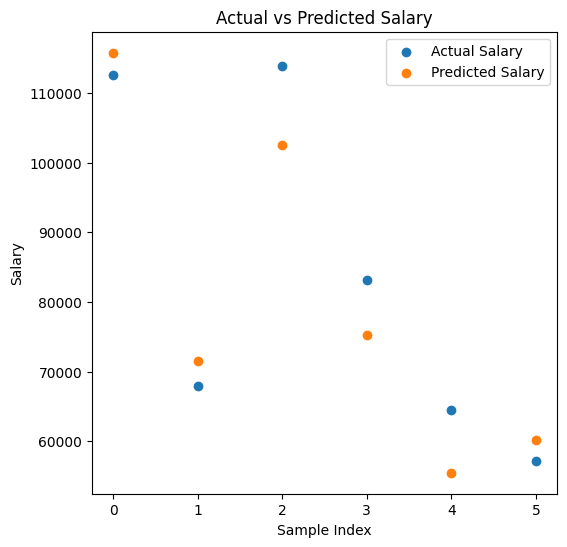

In [ ]:
# Plot Actual vs Predicted values using two different colors

plt.figure(figsize=(6,6))

# Actual values (blue)
plt.scatter(range(len(y_test)), y_test, label="Actual Salary")

# Predicted values (orange)
plt.scatter(range(len(y_pred)), y_pred, label="Predicted Salary")

plt.xlabel("Sample Index")
plt.ylabel("Salary")
plt.title("Actual vs Predicted Salary")

# Show legend so colors are explained
plt.legend()

plt.show()

# Plot Actual vs Predicted values using two different colors

plt.figure(figsize=(6,6))

# Actual values (blue)
plt.scatter(range(len(y_test)), y_test, label="Actual Price")

# Predicted values (orange)
plt.scatter(range(len(y_pred)), y_pred, label="Predicted Price")

plt.xlabel("Sample Index")
plt.ylabel("House Price")
plt.title("Actual vs Predicted Prices")

# Show legend so colors are explained
plt.legend()

plt.show()

Multiple Linear Regression

Importing Important Libraries, We import:

pandas → load dataset

matplotlib/seaborn → visualization

sklearn → machine learning

In [ ]:
# Basic libraries for data handling and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Loading the dataset

In [ ]:
# Load the Boston dataset
df = pd.read_csv("/content/Boston.csv")

# Show first 5 rows
df.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


Check dataset info

In [ ]:
# Number of rows and columns
print(df.shape)

# Column names
print(df.columns)

# Basic statistics
print(df.describe())

(30, 3)


,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


Always remove useless columns before training.

In [ ]:
# Sometimes Boston dataset contains an index column called 'Unnamed: 0'
# It is useless for prediction, so we remove it

if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


# Check if any column has missing values
If any column shows non-zero → handle missing data.

In Boston dataset → usually none.

In [ ]:
# Check if any column has missing values
df.isnull().sum()

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


Visualize correlation (VERY IMPORTANT)

Shows:

which features strongly affect house price

✔ high correlation → important feature

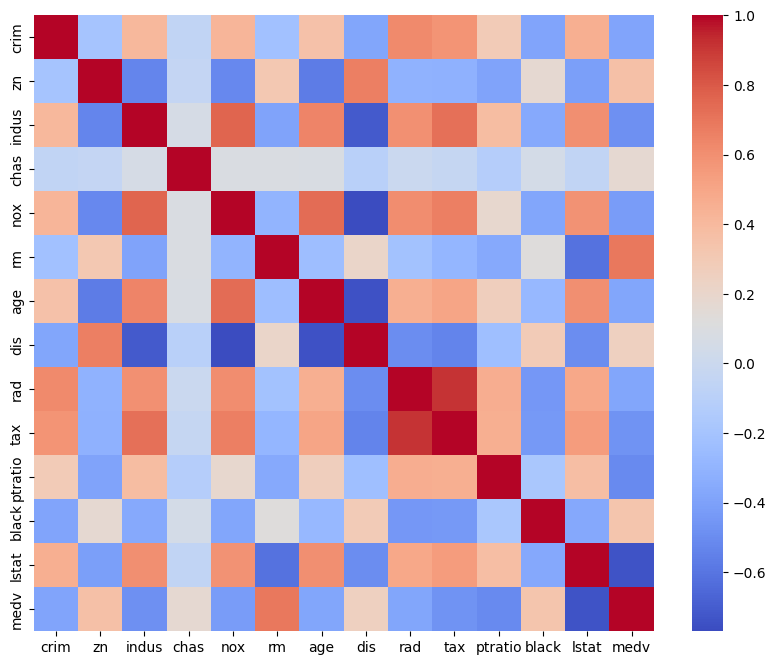

In [ ]:
# Plot correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.show()

Select Features (X) and Target (y)

Simple meaning:

X = inputs (house info)

y = output (price)

In [ ]:
# Target variable (what we want to predict)
y = df['medv']   # median house price

# Features (everything else)
X = df.drop('medv', axis=1)

Train-test split

Train → learn patterns

Test → check accuracy

In [ ]:
# 80% training, 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Create Linear Regression Model

In [ ]:
# Create model
model = LinearRegression()

# Train model using training data
model.fit(X_train, y_train)

LinearRegression()

Predict house prices

In [ ]:
# Predict on test data
y_pred = model.predict(X_test)

# Show first 5 predictions
print(y_pred[:5])

[28.99672362 36.02556534 14.81694405 25.03197915 18.76987992]


Evaluate Model

In [ ]:
# Mean Squared Error (lower is better)
mse = mean_squared_error(y_test, y_pred)

# R2 Score (closer to 1 is better)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 24.291119474973478
R2 Score: 0.6687594935356326


Plot Real vs Predicted Prices

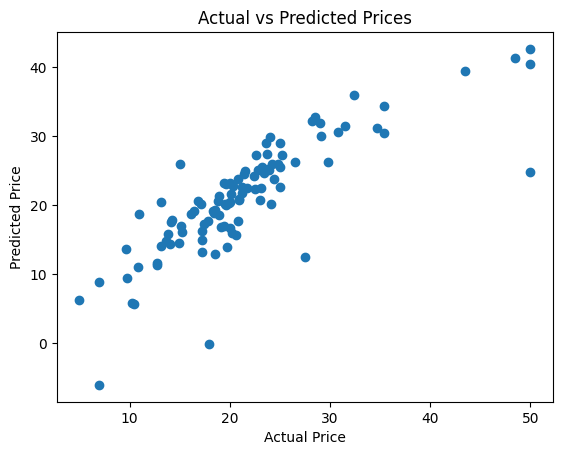

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()
#If points form diagonal line → model is good.

Blue dots → real house prices

Orange dots → model predictions

If dots overlap → model is good

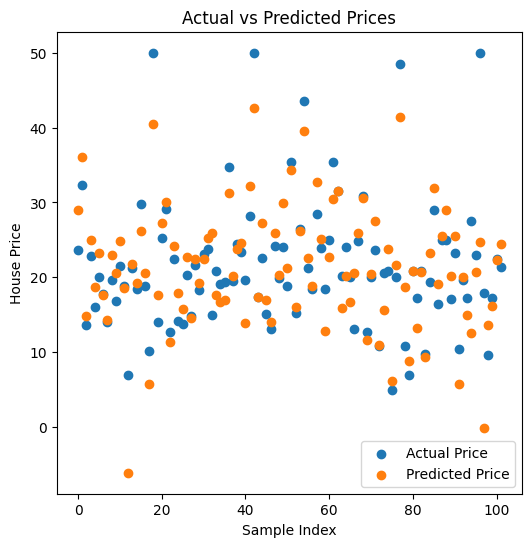

In [ ]:
# Plot Actual vs Predicted values using two different colors

plt.figure(figsize=(6,6))

# Actual values (blue)
plt.scatter(range(len(y_test)), y_test, label="Actual Price")

# Predicted values (orange)
plt.scatter(range(len(y_pred)), y_pred, label="Predicted Price")

plt.xlabel("Sample Index")
plt.ylabel("House Price")
plt.title("Actual vs Predicted Prices")

# Show legend so colors are explained
plt.legend()

plt.show()

Do it your self with another dataset. I am giving you the dataset.